In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 15)


In [6]:
df.to_csv("titanic.csv", index=False)

print("Saved raw Titanic dataset to analytics/titanic.csv")

Saved raw Titanic dataset to analytics/titanic.csv


In [7]:
print("===== DATA INFO =====")
df.info()

print("\n===== DESCRIPTIVE STATISTICS =====")
display(df.describe(include="all"))

print("\n===== DATASET SHAPE =====")
print(df.shape)

===== DATA INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

===== DESCRIPTIVE STATISTICS =====


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== DATASET SHAPE =====
(891, 15)


In [8]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

missing_report = missing_report[missing_report["missing_count"] > 0]

print("===== MISSING VALUE REPORT =====")
display(missing_report)

===== MISSING VALUE REPORT =====


,missing_count,missing_percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [9]:
# Create a copy for cleaning
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (891, 15)


In [10]:
# Handle missing values according to the assignment thresholds

# 1. Under 5% missing -> drop rows
df_clean = df_clean.dropna(
    subset=["embarked", "embark_town"]
)

# 2. 5%-30% missing -> impute
# Age is 19.8653% missing, so use the median.
df_clean["age"] = df_clean["age"].fillna(
    df_clean["age"].median()
)

# 3. Very high missingness -> drop the column
# Deck has 77.2166% missing values.
df_clean = df_clean.drop(columns=["deck"])

print("Cleaned shape:", df_clean.shape)

Cleaned shape: (889, 14)


In [11]:
# Verify that the cleaned dataset has no missing values

print("Remaining missing values:")
display(df_clean.isnull().sum())

Remaining missing values:


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Missing-Value Handling

The missing-value percentages were measured before cleaning:

- `age`: 19.8653% missing → imputed using the median because it falls within the 5%–30% range.
- `embarked`: 0.2245% missing → rows with missing values were dropped because the missing percentage is below 5%.
- `embark_town`: 0.2245% missing → rows with missing values were dropped because the missing percentage is below 5%.
- `deck`: 77.2166% missing → the column was dropped because the missingness is very high and heavy imputation would introduce substantial artificial information.

After applying these decisions, the cleaned dataset contains 889 rows and 14 columns with no remaining missing values.

Cell 1  → Imports
Cell 2  → Load Titanic
Cell 3  → Save titanic.csv
Cell 4  → Profile dataset
Cell 5  → Missing-value report

Cell 6  → Create df_clean
Cell 7  → Calculate missing percentages
Cell 8  → Categorize missing columns
Cell 9  → Apply cleaning
Cell 10 → Handle high-missing column
Cell 11 → Verify cleaned data
Markdown → Explain missing-value decisions

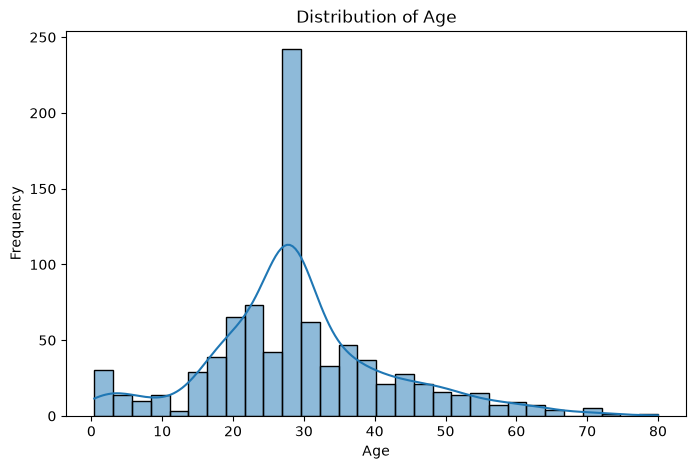

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["age"],
    bins=30,
    kde=True
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

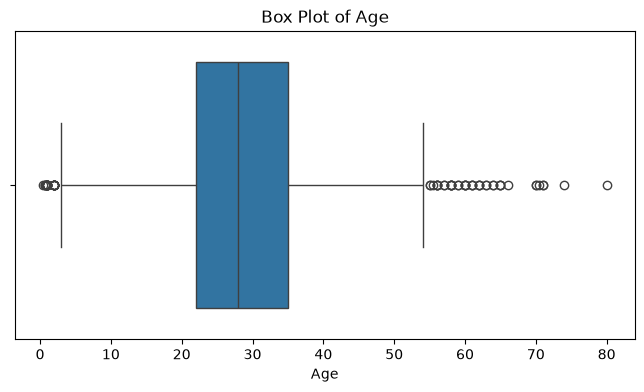

In [13]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["age"]
)

plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

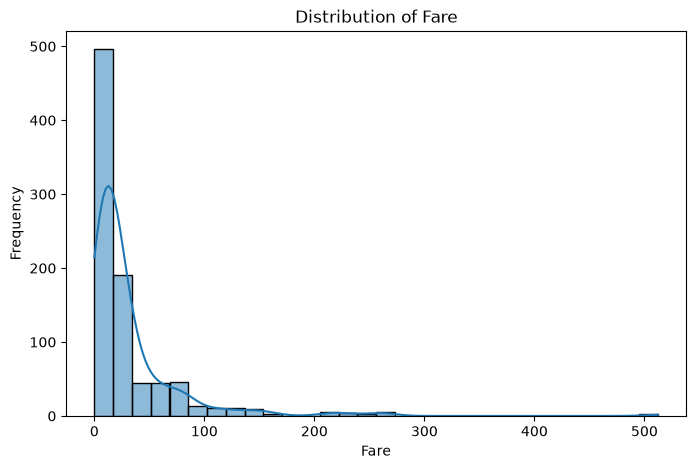

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["fare"],
    bins=30,
    kde=True
)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

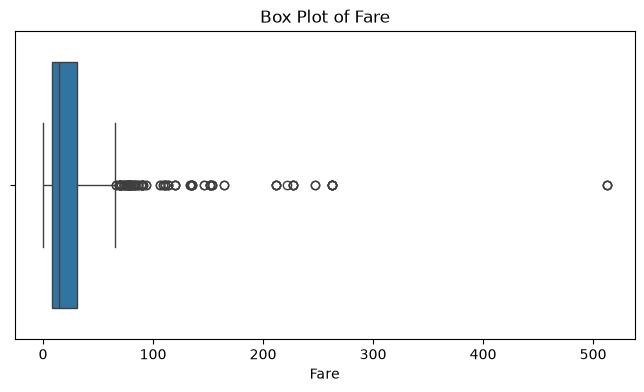

In [15]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["fare"]
)

plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [16]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }


age_outliers = iqr_outlier_count(df_clean["age"])
fare_outliers = iqr_outlier_count(df_clean["fare"])

print("===== AGE IQR OUTLIERS =====")
print(age_outliers)

print("\n===== FARE IQR OUTLIERS =====")
print(fare_outliers)

===== AGE IQR OUTLIERS =====
{'Q1': np.float64(22.0), 'Q3': np.float64(35.0), 'IQR': np.float64(13.0), 'lower_bound': np.float64(2.5), 'upper_bound': np.float64(54.5), 'outlier_count': 65}

===== FARE IQR OUTLIERS =====
{'Q1': np.float64(7.8958), 'Q3': np.float64(31.0), 'IQR': np.float64(23.1042), 'lower_bound': np.float64(-26.7605), 'upper_bound': np.float64(65.6563), 'outlier_count': 114}


In [17]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("===== FARE STATISTICS =====")
print(f"Mean   : {fare_mean:.4f}")
print(f"Median : {fare_median:.4f}")
print(f"Mode   : {fare_mode:.4f}")

===== FARE STATISTICS =====
Mean   : 32.0967
Median : 14.4542
Mode   : 8.0500


In [18]:
if fare_mean > fare_median > fare_mode:
    skew_conclusion = "right-skewed"
elif fare_mean < fare_median < fare_mode:
    skew_conclusion = "left-skewed"
else:
    skew_conclusion = "not strictly determined by mean/median/mode ordering"

print("Fare distribution:", skew_conclusion)

Fare distribution: right-skewed


## Univariate Analysis — Interpretation

### Age

The age distribution was examined using a histogram and box plot. Using the IQR method, the first quartile was 22.0 and the third quartile was 35.0, giving an IQR of 13.0. The resulting upper bound was 54.5, and 65 observations were identified as IQR outliers.

### Fare

The fare distribution was examined using a histogram and box plot. The IQR was 23.1042, with an upper bound of 65.6563, resulting in 114 IQR outliers. The mean fare was 32.0967, the median was 14.4542, and the mode was 8.0500. Since mean > median > mode, the fare distribution is right-skewed.

In [21]:
# Survival rate by sex

survival_by_sex = df_clean.groupby("sex")["survived"].mean()

print("===== SURVIVAL RATE BY SEX =====")
display(survival_by_sex)

===== SURVIVAL RATE BY SEX =====


sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

In [23]:
# Survival rate by passenger class

survival_by_pclass = df_clean.groupby("pclass")["survived"].mean()

print("===== SURVIVAL RATE BY PCLASS =====")
display(survival_by_pclass)

===== SURVIVAL RATE BY PCLASS =====


pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [24]:
# Survival rates by sex and passenger class
# using boolean masking with &

male_first = df_clean[
    (df_clean["sex"] == "male") &
    (df_clean["pclass"] == 1)
]["survived"].mean()

male_second = df_clean[
    (df_clean["sex"] == "male") &
    (df_clean["pclass"] == 2)
]["survived"].mean()

male_third = df_clean[
    (df_clean["sex"] == "male") &
    (df_clean["pclass"] == 3)
]["survived"].mean()

female_first = df_clean[
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 1)
]["survived"].mean()

female_second = df_clean[
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 2)
]["survived"].mean()

female_third = df_clean[
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 3)
]["survived"].mean()

sex_pclass_rates = pd.DataFrame({
    "sex": ["male", "male", "male", "female", "female", "female"],
    "pclass": [1, 2, 3, 1, 2, 3],
    "survival_rate": [
        male_first,
        male_second,
        male_third,
        female_first,
        female_second,
        female_third
    ]
})

print("===== SURVIVAL RATE BY SEX AND PCLASS =====")
display(sex_pclass_rates)

===== SURVIVAL RATE BY SEX AND PCLASS =====


,sex,pclass,survival_rate
0,male,1,0.368852
1,male,2,0.157407
2,male,3,0.135447
3,female,1,0.967391
4,female,2,0.921053
5,female,3,0.500000


In [29]:
# Correlation matrix using exactly the six required columns

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df_clean[correlation_columns].corr()

print("===== CORRELATION MATRIX =====")
display(correlation_matrix)

===== CORRELATION MATRIX =====


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


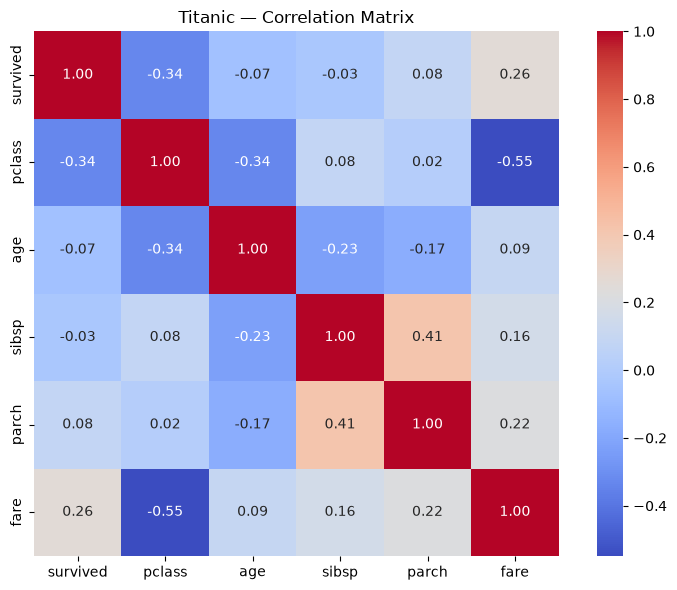

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Titanic — Correlation Matrix")
plt.tight_layout()

# Save chart as a supporting artifact
plt.savefig("charts/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [31]:
# Find the two strongest absolute off-diagonal correlations

corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]

        corr_pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "correlation": corr_value,
            "absolute_correlation": abs(corr_value)
        })

corr_pairs_df = pd.DataFrame(corr_pairs)

top_two_correlations = corr_pairs_df.sort_values(
    "absolute_correlation",
    ascending=False
).head(2)

print("===== TWO STRONGEST CORRELATIONS =====")
display(top_two_correlations)

===== TWO STRONGEST CORRELATIONS =====


,feature_1,feature_2,correlation,absolute_correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


In [32]:
correlation_matrix.to_csv(
    "charts/correlation_matrix.csv"
)

print("Correlation matrix saved.")

Correlation matrix saved.


## Bivariate Analysis — Correlation Interpretation

The correlation matrix was calculated using exactly six numeric columns: `survived`, `pclass`, `age`, `sibsp`, `parch`, and `fare`. The boolean columns `adult_male` and `alone` were excluded as required.

The strongest absolute correlation is between `pclass` and `fare`, with a correlation coefficient of -0.5482. This negative association occurs because a larger `pclass` value represents a lower passenger class, while higher fares are more commonly associated with higher passenger classes.

The second strongest correlation is between `sibsp` and `parch`, with a coefficient of 0.4145. This positive association indicates that passengers traveling with more siblings or spouses also tended, in this dataset, to have more parents or children aboard.

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(
    "charts/survival_by_class_and_sex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

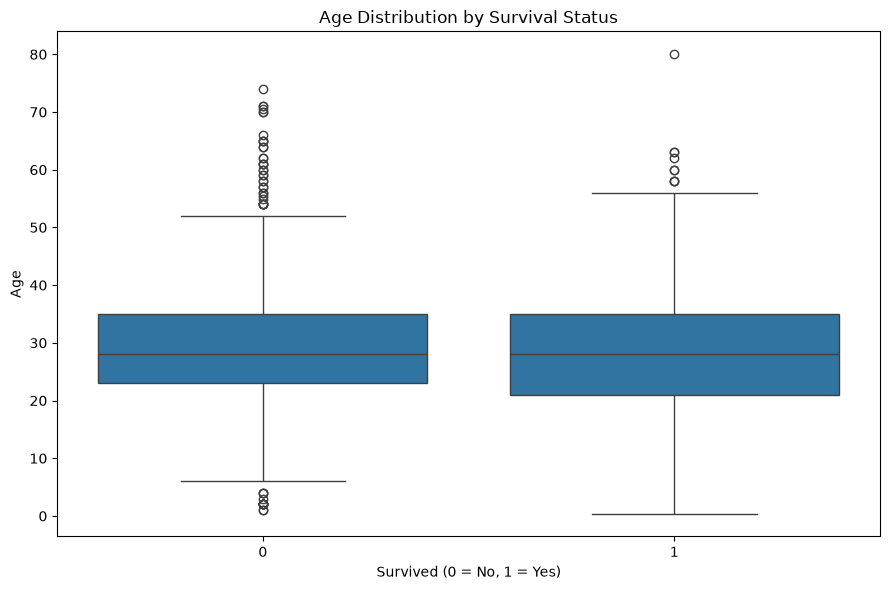

In [33]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.tight_layout()
plt.savefig(
    "charts/age_by_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 2 — Age Distribution by Survival Status

The box plot compares the age distributions of passengers who survived and those who did not. The distributions overlap substantially, showing that age alone does not completely separate the two survival groups. However, differences in the distributions suggest that age may contribute some information to survival prediction when combined with other features.

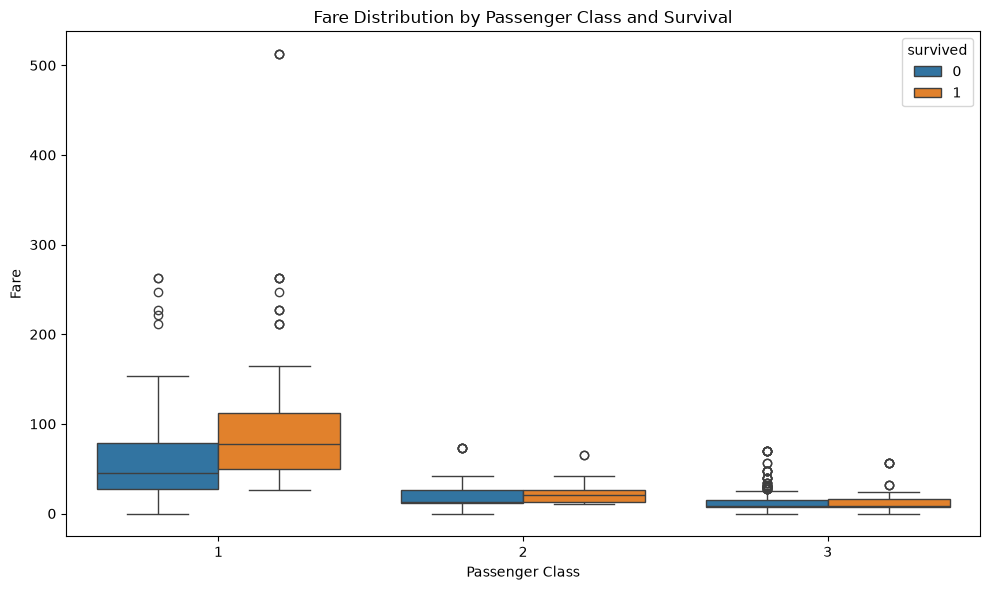

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig(
    "charts/fare_by_class_and_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 3 — Fare by Passenger Class and Survival

Fare distributions differ considerably across passenger classes, consistent with the negative correlation between `pclass` and `fare`. Within each class, the fare distributions of survivors and non-survivors also show differences. This suggests that fare contains information related to passenger class and may provide additional predictive information when combined with other variables.

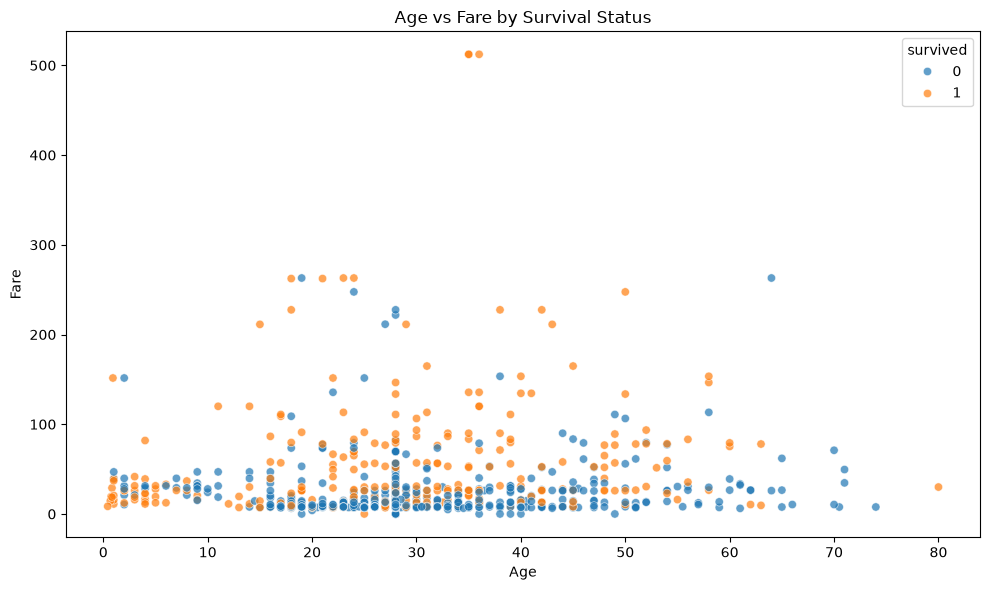

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig(
    "charts/age_vs_fare_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 4 — Age vs Fare by Survival Status

The scatter plot shows the relationship between age and fare while distinguishing passengers by survival status. There is no single age-fare combination that completely separates survivors from non-survivors, indicating that survival is influenced by multiple factors. The concentration of observations across different fare levels also reflects the strong relationship between fare and passenger class.

In [36]:
# Task 6 — Exploratory standardization of age and fare

# Before standardization
before_stats = df_clean[["age", "fare"]].agg(["mean", "std"])

print("===== BEFORE STANDARDIZATION =====")
display(before_stats)

# Standardize age and fare
scaler = StandardScaler()

df_standardized = df_clean.copy()

df_standardized[["age", "fare"]] = scaler.fit_transform(
    df_clean[["age", "fare"]]
)

# After standardization
after_stats = df_standardized[["age", "fare"]].agg(["mean", "std"])

print("===== AFTER STANDARDIZATION =====")
display(after_stats)

===== BEFORE STANDARDIZATION =====


,age,fare
mean,29.315152,32.096681
std,12.984932,49.697504


===== AFTER STANDARDIZATION =====


,age,fare
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00


## Exploratory Standardization

Age and fare were standardized using z-score standardization on the full cleaned DataFrame for exploratory analysis. Before standardization, the two variables had different means and standard deviations. After transformation, both variables have approximately mean 0 and standard deviation 1.

This standardization is used only as an EDA-stage sanity check. It is not used as the modeling pipeline's preprocessing; the modeling pipeline will fit its own `StandardScaler` only on the training data to prevent data leakage.